# Module 7 Homework: PCA

* DS 5001
* Clay Harris: jbm2rt

---
# 1. Setup

In [1]:
OHCO = ['genre', 'author', 'book', 'chapter', 'para_num', 'sent_num', 'token_num']
BAG = ['book']

In [2]:
import pandas as pd
import numpy as np
from scipy.linalg import eigh, norm
import plotly.express as px
import seaborn as sns

sns.set(style='ticks')
%matplotlib inline

---
# 2. Import Data

In [3]:
data_dir = 'HW_7_DATA/'

LIB   = pd.read_csv(data_dir + 'novels-LIB.csv')
VOCAB = pd.read_csv(data_dir + 'novels-VOCAB.csv').set_index('term_id')
TOKEN = pd.read_csv(data_dir + 'novels-TOKENS.csv')

In [4]:
# Deduplicate LIB on book to avoid duplicating tokens
LIB_unique = LIB.drop_duplicates(subset='book', keep='first')

# Merge LIB into TOKEN to get genre and author, then set OHCO index
TOKEN = TOKEN.merge(LIB_unique, on='book', how='left')
TOKEN = TOKEN.set_index(OHCO)
TOKEN.head()

pos  \
genre author   book            chapter para_num sent_num token_num        
d     christie secretadversary 1       0        1        0           DT   
                                                         1          NNP   
                                                         2          NNP   
                                                         3          NNP   
                                       1        0        0           JJ   

                                                                       term_str  \
genre author   book            chapter para_num sent_num token_num                
d     christie secretadversary 1       0        1        0                  the   
                                                         1                young   
                                                         2          adventurers   
                                                         3                  ltd   
                                       1        0        0                tommy   

                                                                    term_id  
genre author   book            chapter para_num sent_num token_num           
d     christie secretadversary 1       0        1        0            24127  
                                                         1            27354  
                                                         2              399  
                                                         3            14406  
                                       1        0        0            24529

---
# 3. Create Bag of Words (BOW) with "book" as the bag

In [5]:
BOW = TOKEN.groupby(BAG + ['term_id']).term_str.count().to_frame().rename(columns={'term_str': 'n'})
BOW.head()

n
book       term_id      
adventures 0        2639
           4           3
           6           1
           19          1
           34          2

---
# 4. Create Document-Term Matrix (DTM) and compute TFIDF

In [6]:
# Pivot BOW into DTM (docs x terms)
DTM = BOW.n.unstack(fill_value=0)
DTM.shape

(20, 27397)

In [7]:
# Compute TF (normalized term frequency per document)
TF = DTM.apply(lambda x: x / x.sum(), axis=1)

# Compute IDF
N_docs = DTM.shape[0]
DF = (DTM > 0).sum()
IDF = np.log10(N_docs / DF)

# Compute TFIDF
TFIDF = TF * IDF
TFIDF.shape

(20, 27397)

---
# 5. Reduce Features

Remove proper nouns (NNP) and keep top terms by `tfidf_sum` from VOCAB. Target: under 4000 terms.

In [8]:
# Identify proper nouns from TOKEN
proper_nouns = TOKEN[TOKEN.pos == 'NNP'].term_id.unique()
print(f"Proper nouns to remove: {len(proper_nouns)}")

# Remove proper nouns from VOCAB
VOCAB_filtered = VOCAB[~VOCAB.index.isin(proper_nouns)]

# Select top 4000 terms by tfidf_sum
top_terms = VOCAB_filtered.sort_values('tfidf_sum', ascending=False).head(4000).index.tolist()

# Filter TFIDF to only these terms (intersect with existing columns)
keep_terms = [t for t in top_terms if t in TFIDF.columns]
TFIDF = TFIDF[keep_terms]
print(f"Reduced TFIDF shape: {TFIDF.shape}")

Proper nouns to remove: 5881
Reduced TFIDF shape: (20, 4000)


---
# 6. Preprocess TFIDF for PCA

Normalize document vector lengths (L2) and center term vectors.

In [9]:
# L2 normalize each document vector
TFIDF = TFIDF.apply(lambda x: x / norm(x), axis=1)

# Center the term vectors (column-wise)
TFIDF = TFIDF - TFIDF.mean()
TFIDF.head()

term_id,24468,19937,20952,13949,15490,1075,5602,11124,14897,1015,...,12308,21967,1306,19309,9726,12971,13872,15052,13871,6081
book,,,,,,,,,,,,,,,,,,,,,
adventures,-0.068517,-0.029761,0.002894,0.0,0.034419,-0.000580,0.051151,-0.017140,0.079305,0.013146,...,-0.002015,0.001483,-0.004731,0.004085,-0.002969,-0.003132,-0.003273,-0.005122,-0.004274,-0.004203
baskervilles,-0.068517,-0.034283,-0.015996,0.0,-0.008370,-0.004852,0.006665,-0.021127,0.024350,0.010878,...,0.003910,-0.005781,-0.004731,-0.004283,-0.002969,-0.003132,0.002059,-0.005122,-0.004274,-0.004203
castleofotranto,0.686855,0.053351,-0.011290,0.0,-0.013105,-0.005133,0.095444,-0.016341,-0.019524,-0.011924,...,-0.002015,-0.005781,0.009375,0.005073,-0.002969,-0.003132,-0.006905,0.001931,-0.004274,-0.004203
christmascarole,-0.068517,0.053008,-0.019717,0.0,0.009304,0.004268,0.199314,0.019659,-0.013443,0.016959,...,-0.002015,0.064326,0.035860,-0.004283,-0.002969,-0.003132,0.004780,-0.005122,0.019095,-0.004203
dracula,-0.068517,-0.008088,0.028307,0.0,-0.003481,-0.005502,-0.016842,-0.001031,0.006771,0.023764,...,-0.002015,-0.005781,-0.004731,0.001776,0.001599,-0.003132,0.006244,-0.000555,0.022024,0.000364


---
# 7. Compute Covariance Matrix

In [10]:
COV = TFIDF.T.dot(TFIDF) / (TFIDF.shape[0] - 1)
COV.iloc[:5, :5].style.background_gradient()

term_id,24468,19937,20952,13949,15490
term_id,,,,,
24468,0.044993,0.002255,-0.000421,0.000000,-0.000831
19937,0.002255,0.001226,-0.000190,0.000000,0.000048
20952,-0.000421,-0.000190,0.000902,0.000000,0.000150
13949,0.000000,0.000000,0.000000,0.000000,0.000000
15490,-0.000831,0.000048,0.000150,0.000000,0.000278


---
# 8. Eigendecomposition

In [11]:
%time eig_vals, eig_vecs = eigh(COV)

CPU times: user 42.2 s, sys: 1.65 s, total: 43.8 s
Wall time: 5.68 s


In [12]:
# Convert to DataFrames
TERM_IDX = COV.index

EIG_VEC = pd.DataFrame(eig_vecs, index=TERM_IDX, columns=TERM_IDX)
EIG_VAL = pd.DataFrame(eig_vals, index=TERM_IDX, columns=['eig_val'])
EIG_VAL.index.name = 'term_id'

EIG_VAL.tail()

,eig_val
term_id,
12971,0.052364
13872,0.053610
15052,0.067641
13871,0.075431
6081,0.091448


---
# 9. Combine Eigenvalues and Eigenvectors

In [13]:
EIG_PAIRS = EIG_VAL.join(EIG_VEC.T)
EIG_PAIRS['exp_var'] = np.round((EIG_PAIRS.eig_val / EIG_PAIRS.eig_val.sum()) * 100, 2)
EIG_PAIRS.head()

,eig_val,24468,19937,20952,13949,15490,1075,5602,11124,14897,...,21967,1306,19309,9726,12971,13872,15052,13871,6081,exp_var
term_id,,,,,,,,,,,,,,,,,,,,,
24468,-1.191165e-16,0.449169,-0.659361,-0.127699,0.136155,0.052776,0.018725,-0.008842,-0.017048,-0.003027,...,0.010617,0.000103,-0.002411,-0.000158,0.003741,0.005376,0.001133,0.005503,0.002964,-0.0
19937,-8.150224e-17,0.006480,0.001554,0.025163,0.131041,-0.007762,-0.016395,-0.059208,-0.030410,-0.309685,...,-0.007427,-0.000558,-0.003075,-0.003143,0.000060,-0.000975,0.004773,-0.000948,-0.004956,-0.0
20952,-7.371407e-17,0.010079,0.012649,0.013284,0.135815,-0.009159,-0.000186,-0.075367,0.023979,-0.196369,...,-0.008349,-0.000397,-0.001741,-0.004295,0.007203,0.002936,0.008365,-0.004500,-0.002492,-0.0
13949,-6.085686e-17,0.028552,-0.017729,-0.007557,0.000789,-0.057208,0.047902,-0.012319,0.018289,-0.520607,...,-0.015364,0.003541,-0.003156,-0.006560,-0.002325,-0.003926,0.020447,-0.008529,-0.000618,-0.0
15490,-5.016368e-17,0.240087,0.071455,0.019161,-0.264651,-0.100390,0.012782,-0.186335,0.123641,0.368538,...,0.012512,-0.003574,0.000672,0.002803,-0.000279,-0.007857,0.008708,0.004419,0.009744,-0.0


<Axes: title={'center': 'Explained Variance by Component'}, xlabel='term_id'>

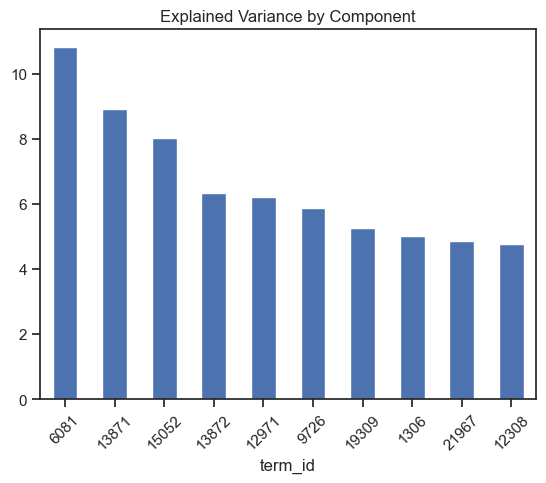

In [14]:
EIG_PAIRS.exp_var.sort_values(ascending=False).head(10).plot.bar(rot=45, title='Explained Variance by Component')

---
# 10. Extract Top 10 Components

In [15]:
COMPS = EIG_PAIRS.sort_values('exp_var', ascending=False).head(10).reset_index(drop=True)
COMPS.index.name = 'comp_id'
COMPS.index = ["PC{}".format(i) for i in COMPS.index.tolist()]
COMPS[['eig_val', 'exp_var']]

,eig_val,exp_var
PC0,0.091448,10.82
PC1,0.075431,8.93
PC2,0.067641,8.01
PC3,0.053610,6.34
PC4,0.052364,6.20
PC5,0.049675,5.88
PC6,0.044386,5.25
PC7,0.042235,5.00
PC8,0.040944,4.85
PC9,0.040107,4.75


---
# 11. Project Documents onto Component Space (DCM)

In [16]:
DCM = TFIDF.dot(COMPS[TERM_IDX].T)

# Add genre and author metadata for visualization
LIB_indexed = LIB_unique.set_index('book')
DCM['genre']  = DCM.index.map(lambda x: LIB_indexed.loc[x, 'genre'])
DCM['author'] = DCM.index.map(lambda x: LIB_indexed.loc[x, 'author'])
DCM.head()

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,genre,author
book,,,,,,,,,,,,
adventures,-0.378786,-0.228479,-0.002845,-0.037990,0.164316,-0.001691,0.064647,-0.009867,0.043307,0.043175,d,doyle
baskervilles,-0.270118,-0.165385,-0.057589,0.042641,0.314994,0.027836,-0.190613,0.415884,-0.417491,-0.144618,d,doyle
castleofotranto,0.655684,-0.427916,-0.318098,0.002060,0.042961,-0.073960,0.022442,0.017445,0.040228,0.013461,g,walpole
christmascarole,-0.163664,-0.102685,0.148210,0.105831,-0.021893,-0.197525,0.512899,-0.002177,0.170898,0.274635,g,dickens
dracula,-0.246957,-0.112281,0.110379,0.059171,0.073537,-0.053033,0.198468,-0.126889,0.292130,-0.098347,g,stoker


---
# 12. Visualize Results

## PC0 vs PC1 — by genre

In [17]:
fig = px.scatter(DCM, 'PC0', 'PC1', color='genre', hover_name=DCM.index, marginal_x='box')
fig.show()

## PC0 vs PC1 — by author

In [18]:
fig = px.scatter(DCM, 'PC0', 'PC1', color='author', hover_name=DCM.index, marginal_x='box')
fig.show()

## PC1 vs PC2 — by genre

In [19]:
fig = px.scatter(DCM, 'PC1', 'PC2', color='genre', hover_name=DCM.index, marginal_x='box')
fig.show()

## PC1 vs PC2 — by author

In [20]:
fig = px.scatter(DCM, 'PC1', 'PC2', color='author', hover_name=DCM.index, marginal_x='box')
fig.show()

---
# 13. Loadings — Positive and Negative

In [21]:
LOADINGS = COMPS[TERM_IDX].T
LOADINGS.index.name = 'term_id'
LOADINGS['term_str'] = LOADINGS.apply(lambda x: VOCAB.loc[int(x.name)].term_str, 1)

In [22]:
pc0_pos = LOADINGS.sort_values('PC0', ascending=False).head(10).term_str.str.cat(sep=' ')
pc0_neg = LOADINGS.sort_values('PC0', ascending=True).head(10).term_str.str.cat(sep=' ')
pc1_pos = LOADINGS.sort_values('PC1', ascending=False).head(10).term_str.str.cat(sep=' ')
pc1_neg = LOADINGS.sort_values('PC1', ascending=True).head(10).term_str.str.cat(sep=' ')

print('PC0 positive:', pc0_pos)
print('PC0 negative:', pc0_neg)
print('PC1 positive:', pc1_pos)
print('PC1 negative:', pc1_neg)

PC0 positive: tm electronic kinsmen kneeled commissioners divorce strove enquire ebooks quitted
PC0 negative: launch cab footnote baronet ami car asked hardly taxi stepfather
PC1 positive: corpse ebony descent shrill panes fro contention bandage sooth mode
PC1 negative: tm electronic cried kinsmen cab footnote divorce launch ami baronet


---
# 14. Interpretation of Top Two Components

**PC0** (10.82% explained variance) separates texts along what appears to be a **period/modernity axis**. The positive loadings include archaic and formal terms (e.g., "kinsmen," "kneeled," "strove," "quitted") along with Project Gutenberg artifacts ("tm," "electronic," "ebooks"), suggesting older public-domain texts. The negative loadings feature vocabulary associated with detective fiction and modern settings ("cab," "taxi," "car," "baronet," "stepfather," "asked"). PC0 thus primarily distinguishes older, more literary texts from modern detective novels.

**PC1** (8.93% explained variance) captures a **gothic/horror thematic dimension**. The positive loadings include words strongly associated with gothic atmosphere and horror ("corpse," "ebony," "shrill," "descent," "bandage," "sooth"), suggesting this component picks up on the gothic genre's distinctive vocabulary of dread and the supernatural. The negative end mixes detective and miscellaneous terms. PC1 thus separates gothic novels from the rest of the corpus orthogonally to the period distinction in PC0.